# 01 — HI 21-cm Intensity Mapping Model

The 21-cm hydrogen line traces large-scale structure via intensity mapping.
This notebook walks through the Padmanabhan, Refregier \& Amara (2017) HI halo
model: HI mass assignment, modified NFW profile, mean density, brightness
temperature, effective bias, and HI power spectra. The Cunnington et al. (2025)
data-calibrated polynomials are shown alongside for comparison.

**References:** `docs/equations.md` §3 (Eqs. 3.1–3.13d); Padmanabhan+ (2017);
Pinetti+ (2020) Eqs. 3.2–3.16; Cunnington+ (2025) Eqs. A3–A5.

In [25]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'hi_gamma_xcorr').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from hi_gamma_xcorr import config as cfg, cosmology as cosmo
from hi_gamma_xcorr import plotting as sty
cosmo.init()
print("Pipeline initialized.")

Pipeline initialized.


In [26]:
from hi_gamma_xcorr import halo_model as hm, hi_model as hi
from hi_gamma_xcorr import pinetti2022 as p22

\
## 1. HI Mass–Halo Mass Relation (Eq. 3.1)

$$M_\mathrm{HI} = \alpha\,f_{H,c}\,M\!\left(\frac{M}{10^{11}h^{-1}M_\odot}\right)^\beta
\exp\!\left[-\left(\frac{v_{c,0}}{v_c(M,z)}\right)^3\right]$$

with $\alpha=0.176$, $\beta=-0.69$, $v_{c,0}=40.7$ km/s.

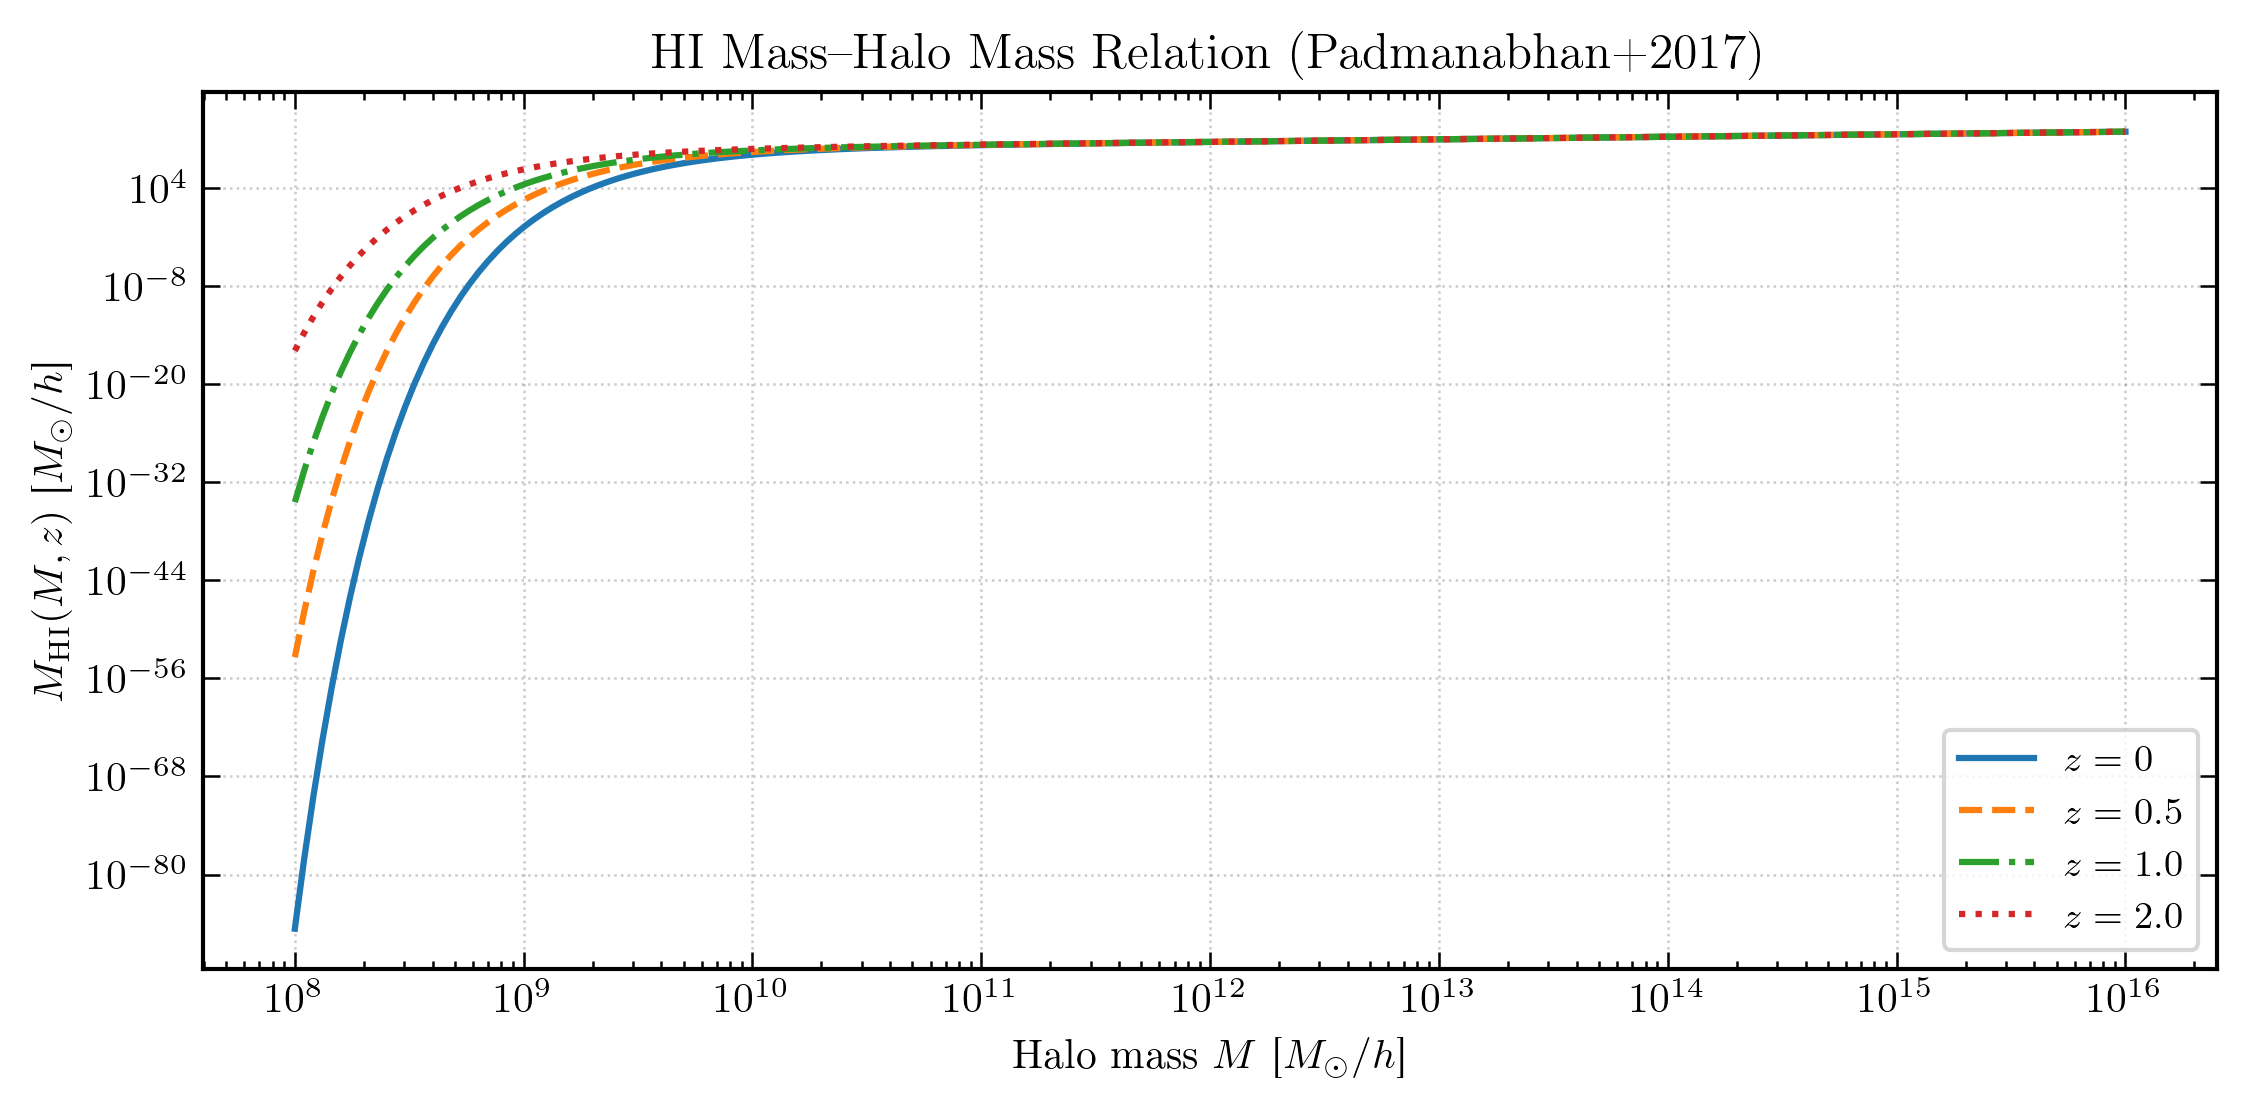

In [27]:
M_arr = np.logspace(8, 16, 200)
fig, ax = sty.textwidth_figure(8)
for z, ls in [(0, '-'), (0.5, '--'), (1.0, '-.'), (2.0, ':')]:
    mhi = np.array([hi.M_HI(M, z) for M in M_arr])
    ax.loglog(M_arr, mhi, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax.set_xlabel(r'Halo mass $M$ [$M_\odot/h$]')
ax.set_ylabel(r'$M_\mathrm{HI}(M,z)$ [$M_\odot/h$]')
ax.set_title('HI Mass--Halo Mass Relation (Padmanabhan+2017)')
ax.legend(); fig.tight_layout()

## 2. HI Concentration (Eq. 3.2)

$$c_\mathrm{HI} = c_{\mathrm{HI},0}\left(\frac{M}{10^{11}M_\odot}\right)^{-0.109}
\frac{4}{(1+z)^\gamma},\qquad c_{\mathrm{HI},0}=139,\;\gamma=0.13$$

HI is much more concentrated than DM ($c_\mathrm{HI} \gg c_\mathrm{vir}$).
The DM concentration uses the Correa et al. (2015) Planck Appendix B1 fit
(**D2**: different coefficients from the thesis Eq. 3.36 fit).

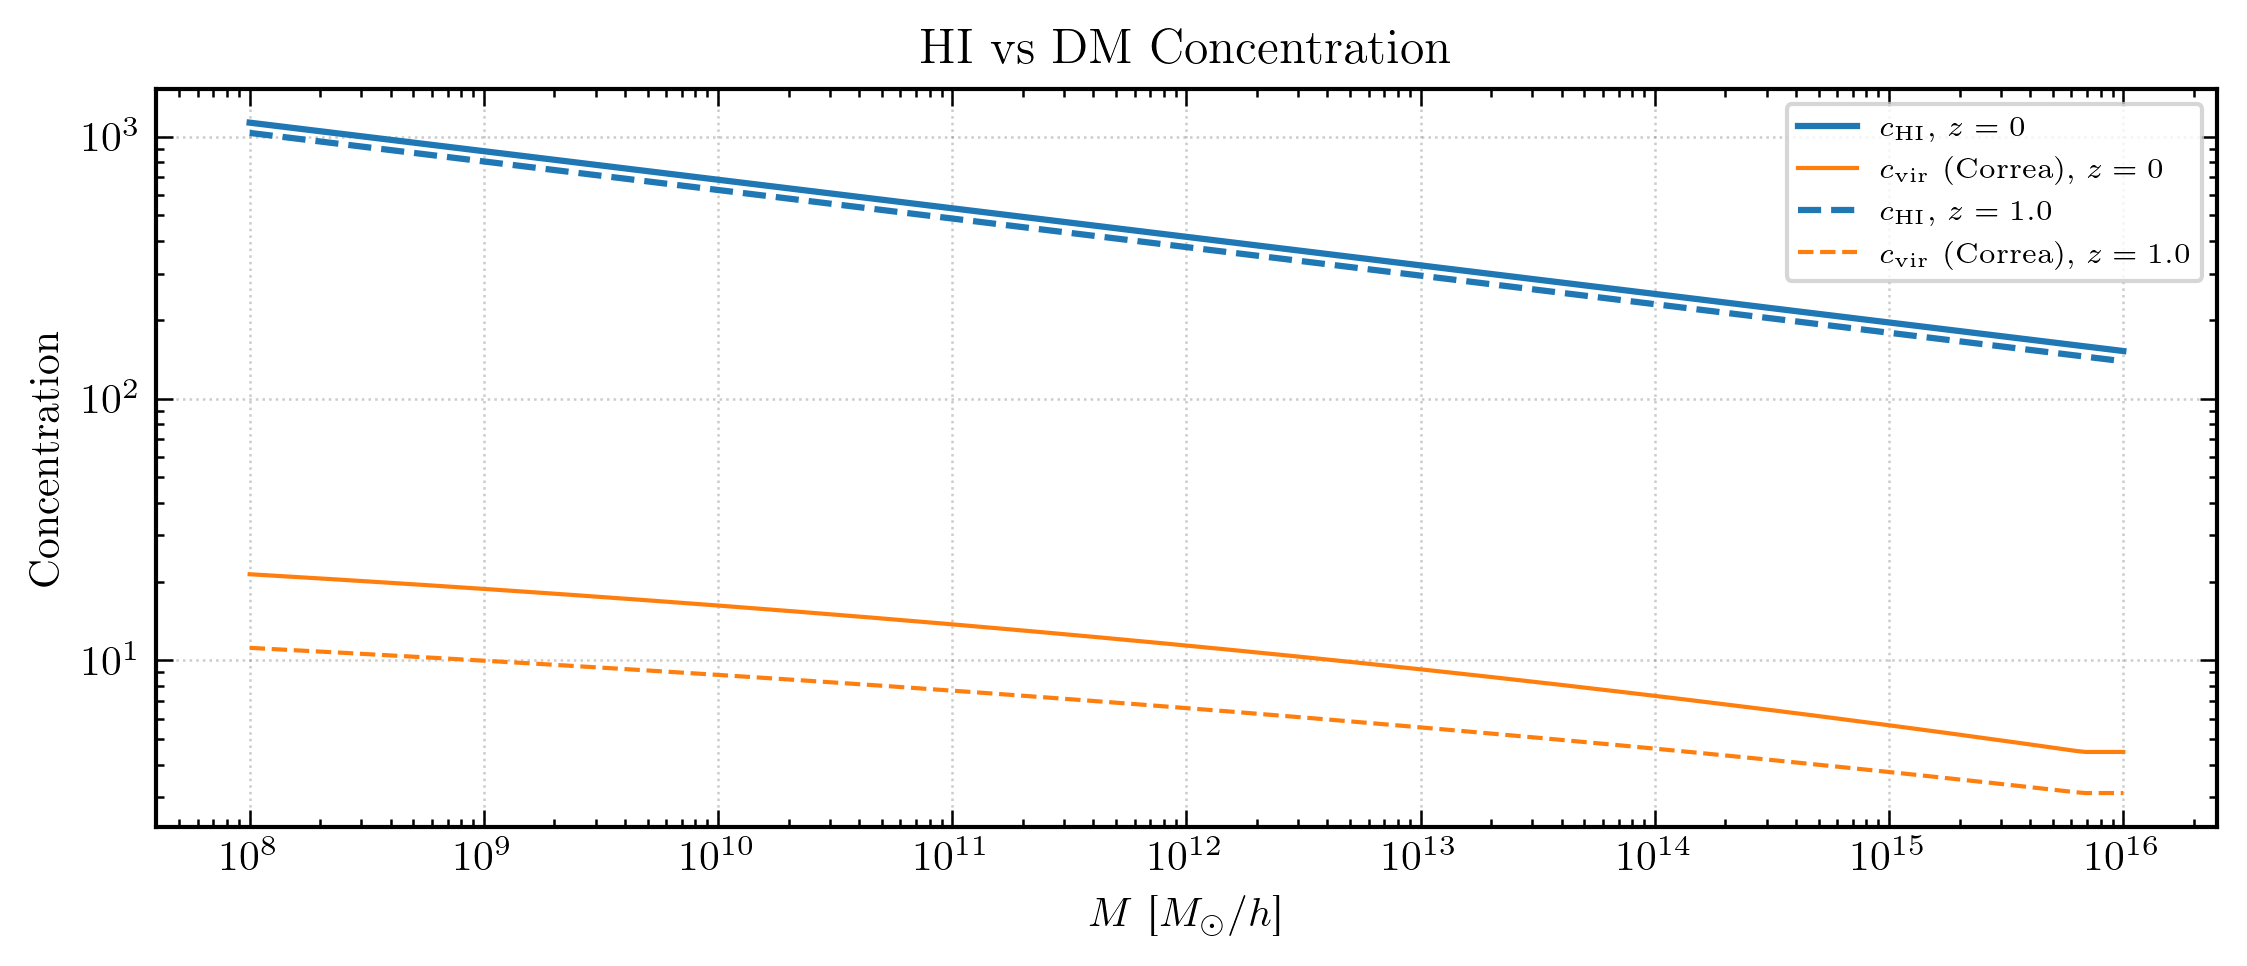

In [28]:
fig, ax = sty.textwidth_figure(7)
for z, ls in [(0, '-'), (1.0, '--')]:
    chi_arr = np.array([hi.c_HI(M, z) for M in M_arr])
    cdm_arr = np.array([hm.concentration(M, z) for M in M_arr])
    ax.loglog(M_arr, chi_arr, ls=ls, color='C0', lw=sty.LW_STANDARD,
              label=rf'$c_{{\mathrm{{HI}}}}$, $z={z}$')
    ax.loglog(M_arr, cdm_arr, ls=ls, color='C1', lw=sty.LW_LIGHT,
              label=rf'$c_{{\mathrm{{vir}}}}$ (Correa), $z={z}$')
ax.set_xlabel(r'$M$ [$M_\odot/h$]'); ax.set_ylabel('Concentration')
ax.set_title('HI vs DM Concentration'); ax.legend(fontsize=sty.LEGEND_SIZE); fig.tight_layout()

\
## 3. HI Profile Fourier Transform (Eq. 3.5)

$$\tilde{u}_\mathrm{HI}(k \mid M) = \frac{4\pi}{M_\mathrm{HI}}
\int_0^{R_\mathrm{vir}} r^2\,\rho_\mathrm{HI}(r)\,\frac{\sin kr}{kr}\,dr$$

The modified NFW inner slope ($r + 0.75\,r_s$ instead of $r$) makes the HI
profile broader in Fourier space than the standard NFW.

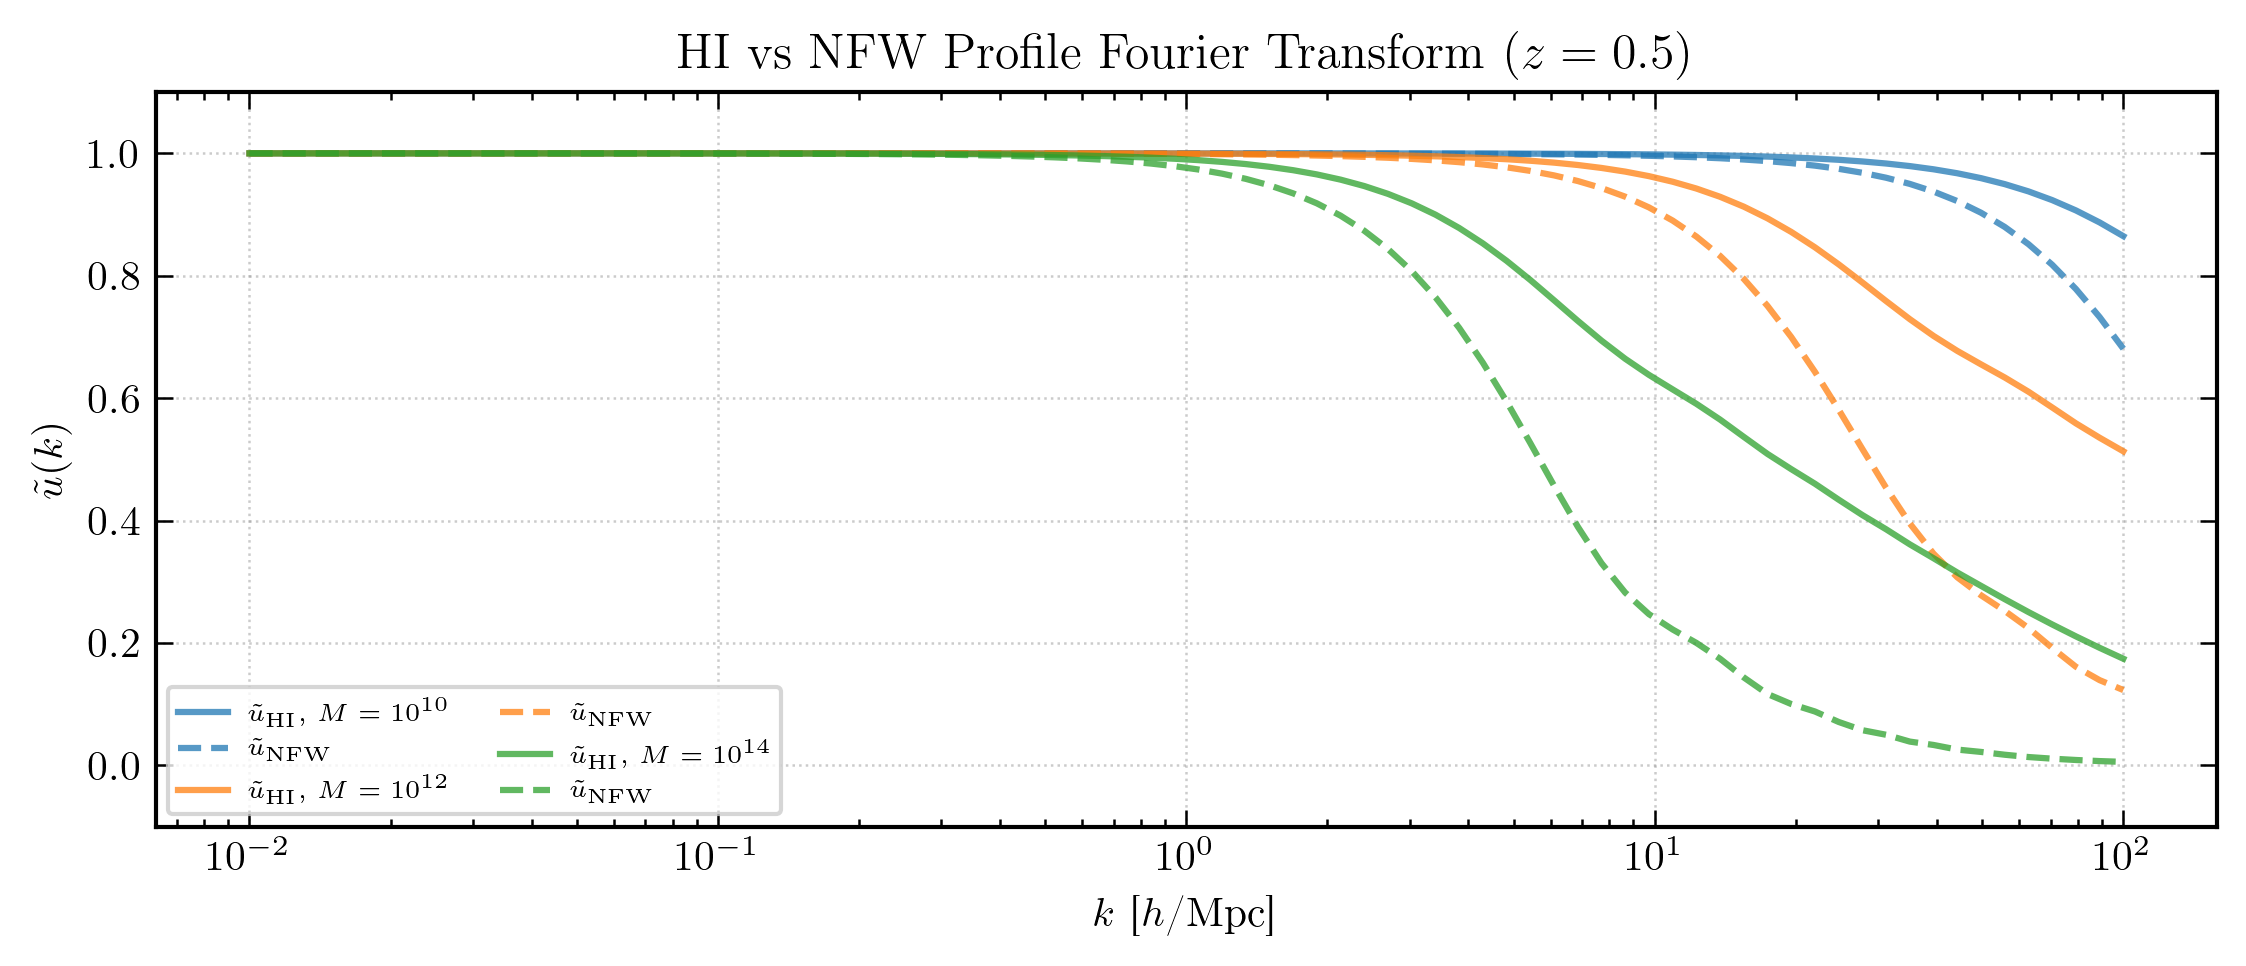

In [29]:
k_arr = np.logspace(-2, 2, 80)
fig, ax = sty.textwidth_figure(7)
z = 0.5
for M, color in [(1e10, 'C0'), (1e12, 'C1'), (1e14, 'C2')]:
    u_hi = hi.u_HI(k_arr, M, z)
    u_dm = hm.u_nfw(k_arr, M, z)
    ax.semilogx(k_arr, u_hi, color=color, **sty.FIT_STYLE,
                label=rf'$\tilde u_{{\mathrm{{HI}}}}$, $M=10^{{{int(np.log10(M))}}}$')
    ax.semilogx(k_arr, u_dm, color=color, **sty.MODEL_STYLE,
                label=rf'$\tilde u_{{\mathrm{{NFW}}}}$')
ax.set_xlabel(r'$k$ [$h$/Mpc]'); ax.set_ylabel(r'$\tilde u(k)$')
ax.set_title(f'HI vs NFW Profile Fourier Transform ($z={z}$)')
ax.legend(fontsize=sty.TICK_SIZE, ncol=2); ax.set_ylim(-0.1, 1.1); fig.tight_layout()

## 4. Mean HI Density $\Omega_\mathrm{HI}(z)$ (Eqs. 3.6–3.7)

$$\Omega_\mathrm{HI}(z) = \bar\rho_\mathrm{HI}^\mathrm{com}(z) / \rho_c$$

Three prescriptions: halo integral (Padmanabhan+2017), Cunnington+2025
polynomial (Eq. A5), and fixed $\Omega_\mathrm{HI}=2.45\times10^{-4}$ (Pinetti).

**D5:** The pipeline computes $\Omega_\mathrm{HI}(z)$ from the halo integral
rather than using a fixed constant. This is more physical but gives a
z-dependent result that differs slightly from the Pinetti thesis value.

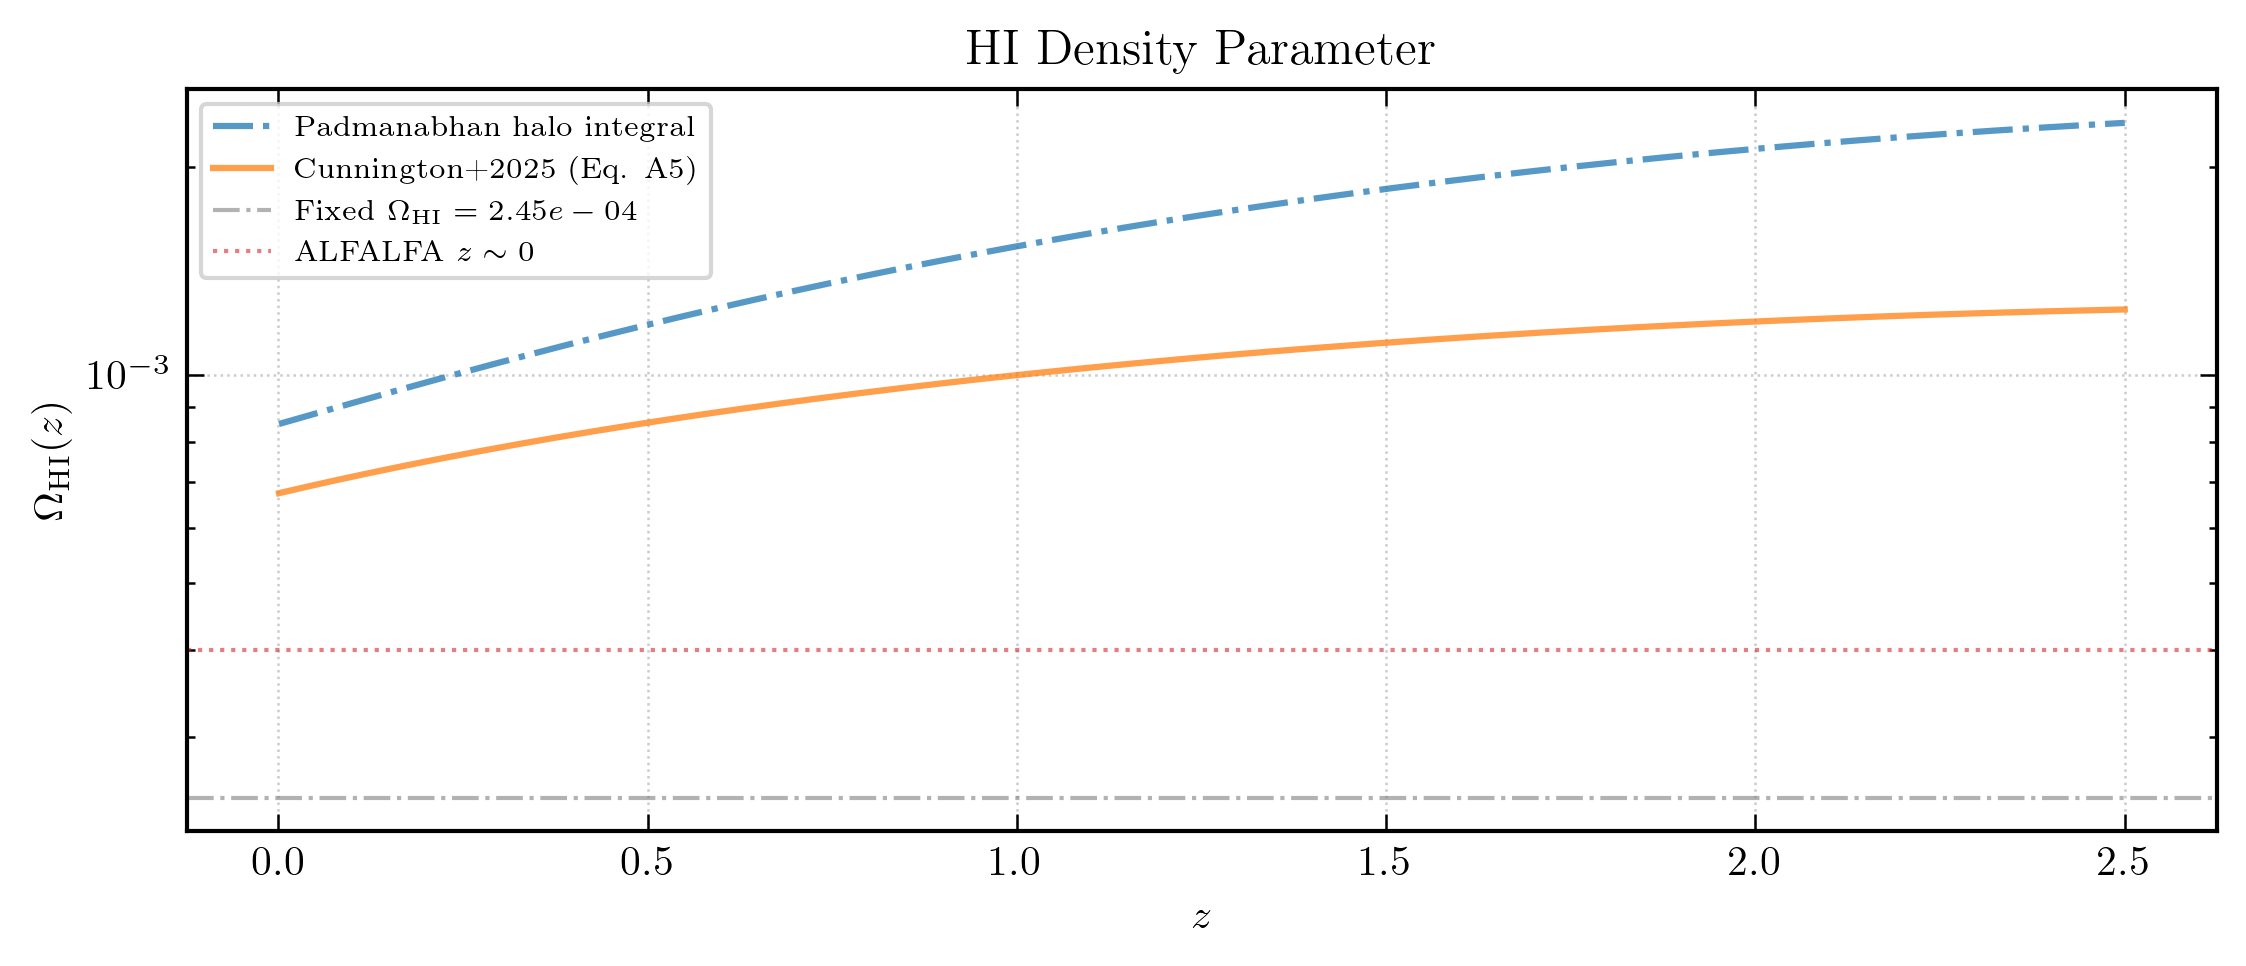

In [30]:
z_arr = np.linspace(0.001, 2.5, 200)
omega_pad = np.array([hi.Omega_HI(z) for z in z_arr])
omega_cunn = hi.Omega_HI_cunnington(z_arr)

fig, ax = sty.textwidth_figure(7)
ax.semilogy(z_arr, omega_pad, **sty.DASHDOT_STYLE, label='Padmanabhan halo integral')
ax.semilogy(z_arr, omega_cunn, **sty.FIT_STYLE, label='Cunnington+2025 (Eq. A5)')
ax.axhline(cfg.OMEGA_HI_FIXED, **sty.GUIDE_STYLE,
           label=rf'Fixed $\Omega_{{\mathrm{{HI}}}}={cfg.OMEGA_HI_FIXED:.2e}$')
ax.axhline(4e-4, ls=':', color='C3', lw=sty.LW_LIGHT, alpha=sty.ALPHA_LIGHT, label=r'ALFALFA $z\sim0$')
ax.set_xlabel('$z$'); ax.set_ylabel(r'$\Omega_\mathrm{HI}(z)$')
ax.set_title(r'HI Density Parameter'); ax.legend(fontsize=sty.LEGEND_SIZE); fig.tight_layout()

## 5. Brightness Temperature $\bar{T}_b(z)$ (Eqs. 3.8, 3.13c)

$$\bar{T}_b = 188\,h\,\Omega_\mathrm{HI}(z)\,\frac{(1+z)^2}{E(z)}\;\mathrm{mK}
\qquad\text{(Padmanabhan)},\qquad
\bar{T}_b^\mathrm{cunn} = 180\,h\,\Omega_\mathrm{HI}^\mathrm{cunn}(z)\,\frac{(1+z)^2}{E(z)}\;\mathrm{mK}$$

The Cunnington+2025 mode (**D15**) uses 180 mK (Battye+2013) instead of
188 mK, with a data-calibrated $\Omega_\mathrm{HI}(z)$ polynomial.
The Pinetti thesis pre-evaluates the 188 mK form at the fixed
$\Omega_\mathrm{HI} = 2.45\times10^{-4}$ to give 44 $\mu$K.

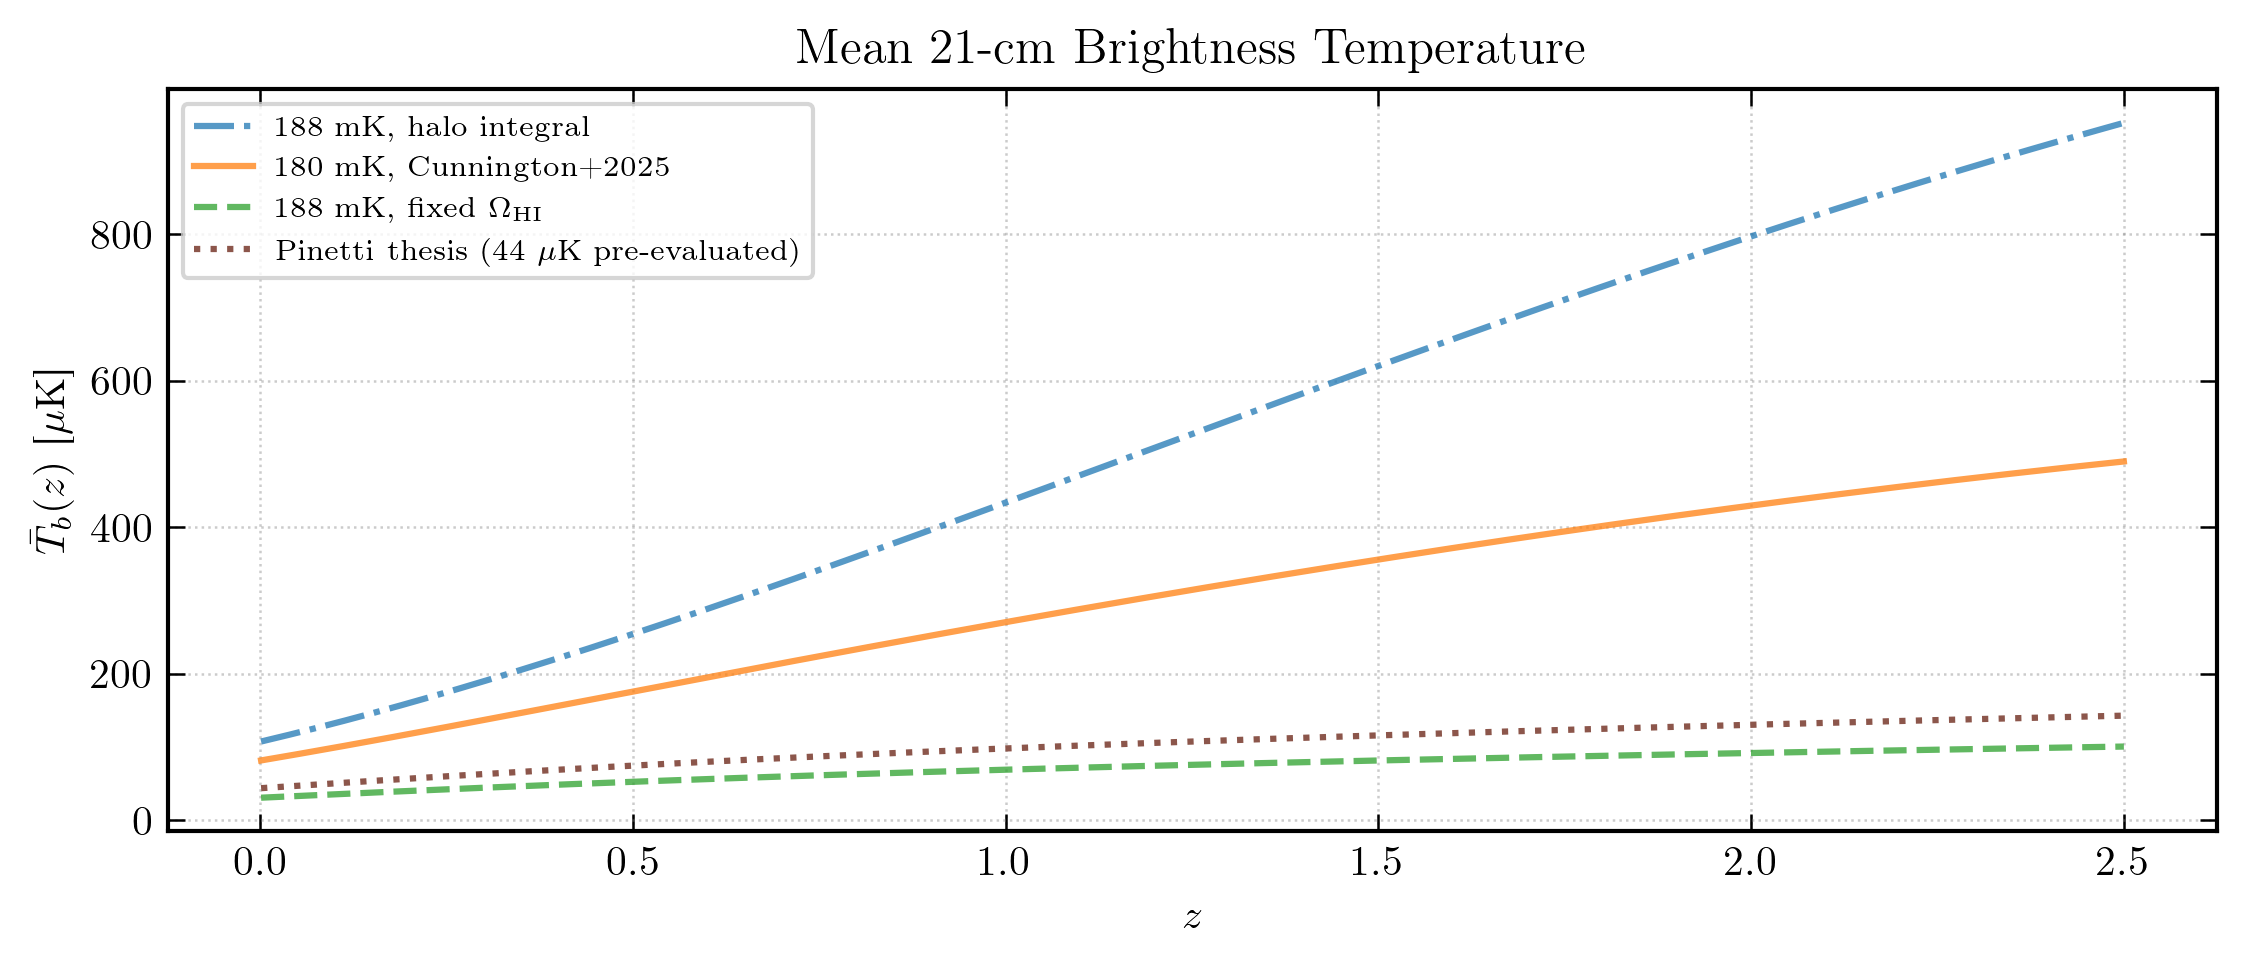

In [31]:
Tb_pad = np.array([hi.T_bar_b(z) for z in z_arr])
Tb_cunn = hi.T_bar_b_cunnington(z_arr)
Tb_fixed = np.array([hi.T_bar_b_fixed_omega(z) for z in z_arr])
Tb_thesis = np.array([p22.T_bar_b_thesis(z) for z in z_arr])

fig, ax = sty.textwidth_figure(7)
ax.plot(z_arr, Tb_pad * 1e3, **sty.DASHDOT_STYLE, label='188 mK, halo integral')
ax.plot(z_arr, Tb_cunn * 1e3, **sty.FIT_STYLE, label='180 mK, Cunnington+2025')
ax.plot(z_arr, Tb_fixed * 1e3, **sty.MODEL_STYLE, label=r'188 mK, fixed $\Omega_\mathrm{HI}$')
ax.plot(z_arr, Tb_thesis * 1e3, ls=':', color='C5', lw=sty.LW_STANDARD,
        label=r'Pinetti thesis (44 $\mu$K pre-evaluated)')
ax.set_xlabel('$z$'); ax.set_ylabel(r'$\bar{T}_b(z)$ [$\mu$K]')
ax.set_title('Mean 21-cm Brightness Temperature'); ax.legend(fontsize=sty.LEGEND_SIZE); fig.tight_layout()

## 6. Effective HI Bias $b_\mathrm{HI}(z)$ (Eqs. 3.9, 3.13b)

$$b_\mathrm{HI} = \frac{1}{\bar\rho_\mathrm{HI}}\int\frac{dn}{dM}\,M_\mathrm{HI}\,b(M,z)\,dM
\qquad\text{or}\qquad
b_\mathrm{HI}^\mathrm{cunn}(z) = 0.842 + 0.693\,z - 0.0459\,z^2$$

The halo-integral bias uses $q = 0.707$ (**D6**); the Pinetti thesis uses
$q = 0.75$. The Cunnington polynomial (**D15**) bypasses the halo integral entirely.

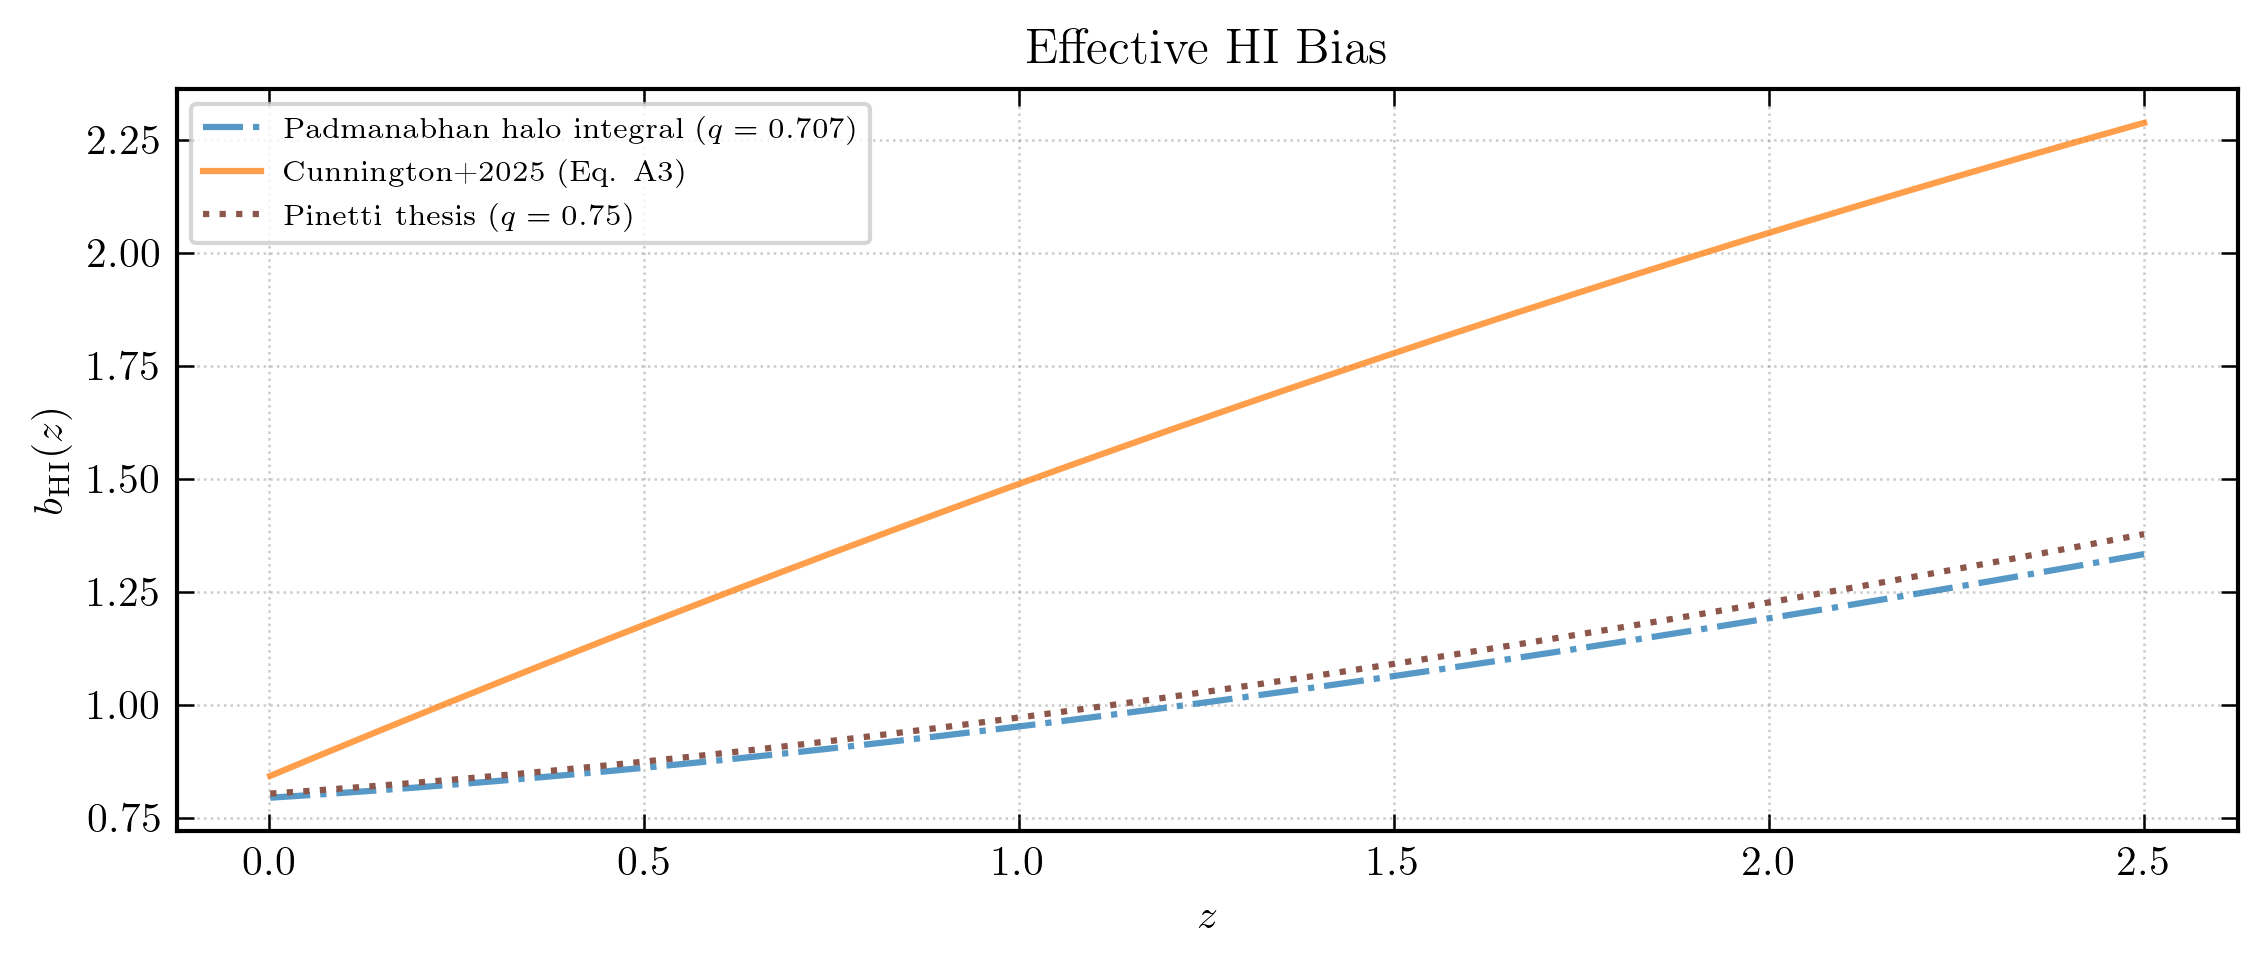

In [32]:
b_pad = np.array([hi.b_HI(z) for z in z_arr])
b_cunn = hi.b_HI_cunnington(z_arr)
b_thesis = np.array([p22.b_HI_pinetti(z) for z in z_arr])

fig, ax = sty.textwidth_figure(7)
ax.plot(z_arr, b_pad, **sty.DASHDOT_STYLE, label='Padmanabhan halo integral ($q=0.707$)')
ax.plot(z_arr, b_cunn, **sty.FIT_STYLE, label='Cunnington+2025 (Eq. A3)')
ax.plot(z_arr, b_thesis, ls=':', color='C5', lw=sty.LW_STANDARD,
        label='Pinetti thesis ($q=0.75$)')
ax.set_xlabel('$z$'); ax.set_ylabel(r'$b_\mathrm{HI}(z)$')
ax.set_title('Effective HI Bias'); ax.legend(fontsize=sty.LEGEND_SIZE); fig.tight_layout()

## 7. HI Power Spectra (Eqs. 3.10–3.11)

One-halo (Poisson) and two-halo (clustering) terms:
$$P_\mathrm{HI}^\mathrm{1h} \propto \int\frac{dn}{dM}\,M_\mathrm{HI}^2\,\tilde{u}_\mathrm{HI}^2\,dM,\qquad
P_\mathrm{HI}^\mathrm{2h} = \bigl[I_\mathrm{HI}^\mathrm{2h}(k,z)\bigr]^2\,P_\mathrm{lin}(k,z)$$

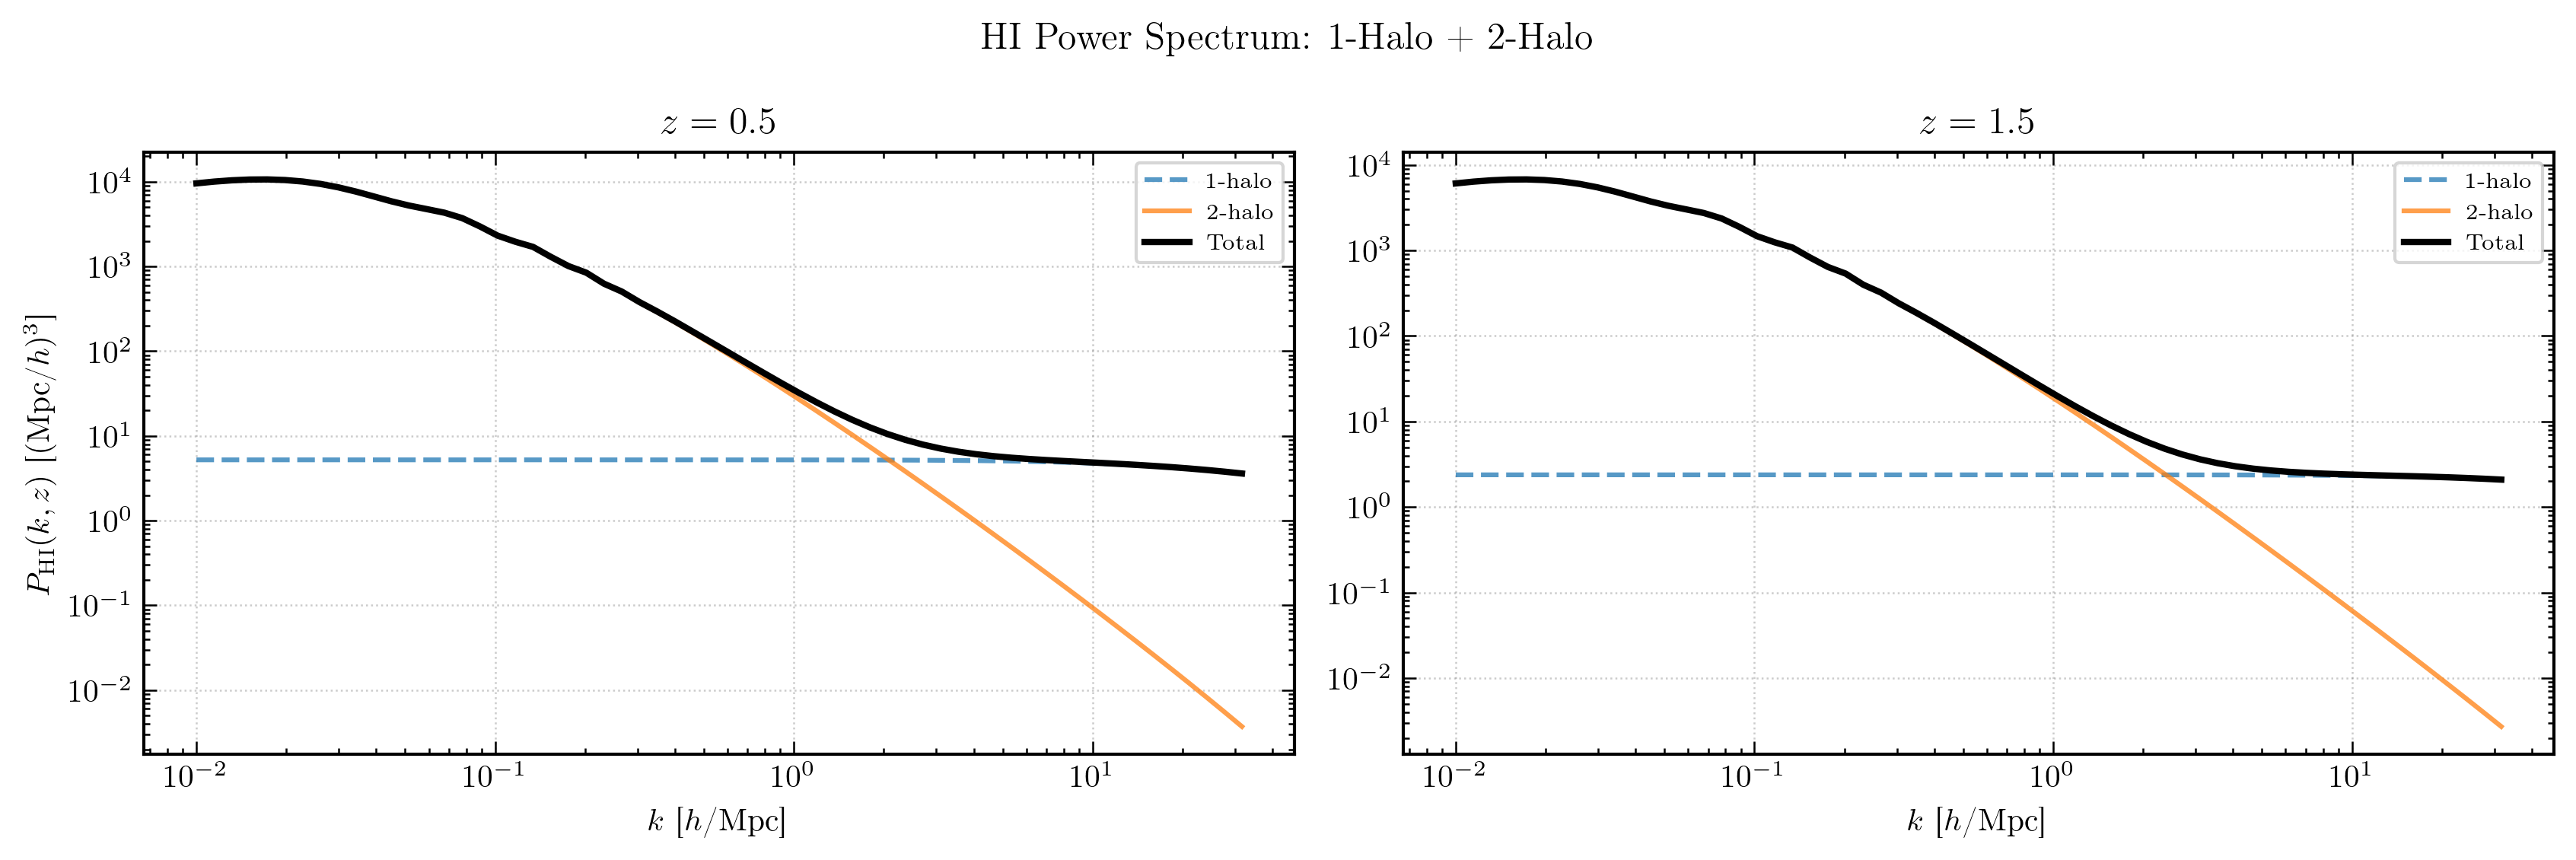

In [33]:
k_ps = np.logspace(-2, 1.5, 60)
fig, axes = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.5, sty.TEXTWIDTH_IN * 0.5))
for iz, (z, ax) in enumerate(zip([0.5, 1.5], axes)):
    p1h = hi.P_HI_1h(k_ps, z, n_M=40)
    p2h = hi.P_HI_2h(k_ps, z, n_M=40)
    ax.loglog(k_ps, p1h, **sty.MODEL_STYLE, label='1-halo')
    ax.loglog(k_ps, p2h, **sty.FIT_STYLE, label='2-halo')
    ax.loglog(k_ps, p1h + p2h, color='k', lw=sty.LW_MEDIUM, label='Total')
    ax.set_xlabel(r'$k$ [$h$/Mpc]'); ax.set_title(f'$z = {z}$')
    ax.legend(fontsize=sty.LEGEND_SIZE)
axes[0].set_ylabel(r'$P_\mathrm{HI}(k,z)$ [(Mpc/$h$)$^3$]')
fig.suptitle('HI Power Spectrum: 1-Halo + 2-Halo'); fig.tight_layout()

\
## 8. The $I_\mathrm{HI}^\mathrm{2h}$ Kernel

$$I_\mathrm{HI}^\mathrm{2h}(k,z) = \frac{1}{\bar\rho_\mathrm{HI}}\sum_M
\frac{dn}{dM}\,b(M)\,M_\mathrm{HI}\,\tilde{u}_\mathrm{HI}(k,M)\,M\,\Delta\ln M$$

This is the shared building block for $P_\mathrm{HI}^\mathrm{2h}$,
$P_{\mathrm{HI}\times\mathrm{astro}}^\mathrm{2h}$, and
$P_{\mathrm{HI}\times\mathrm{DM}}^\mathrm{2h}$.

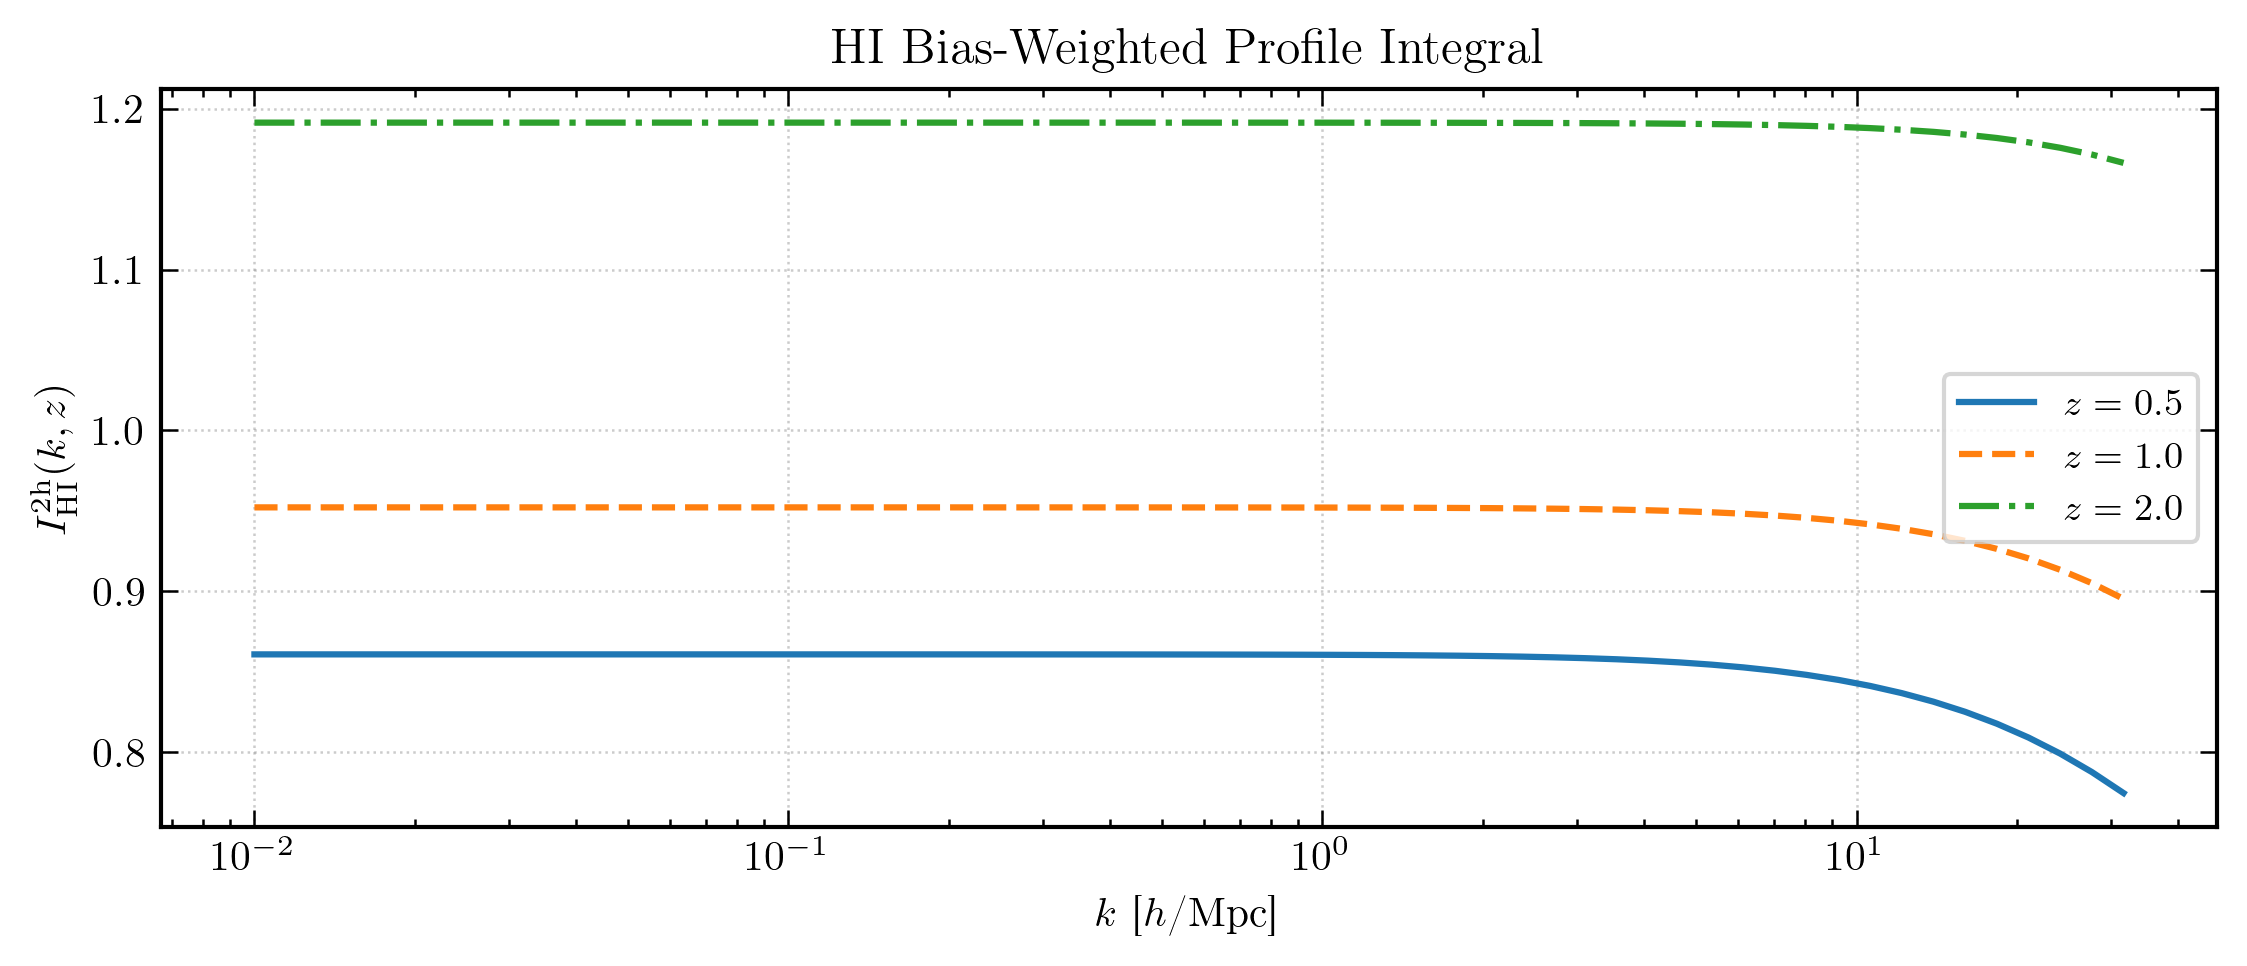

In [34]:
fig, ax = sty.textwidth_figure(7)
for z, ls in [(0.5, '-'), (1.0, '--'), (2.0, '-.')]:
    I = hi.I_HI_2h(k_ps, z, n_M=40)
    ax.semilogx(k_ps, I, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax.set_xlabel(r'$k$ [$h$/Mpc]'); ax.set_ylabel(r'$I_\mathrm{HI}^\mathrm{2h}(k,z)$')
ax.set_title(r'HI Bias-Weighted Profile Integral'); ax.legend(); fig.tight_layout()

\
## 9. HI Window Function (Eq. 3.12)

$$W_\mathrm{HI}(\chi) = \bar{T}_b(z)\,\phi(z)\,\frac{H(z)}{c\,h},\qquad
\phi(z) = \frac{1}{z_\mathrm{max}-z_\mathrm{min}}$$

The window is nonzero only within the radio band's redshift range.

<>:7: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:7: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_902868/1313948245.py:7: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  ax.plot(z_w, W, lw=sty.LW_STANDARD, label=f'{tel} {band} ($z \in [{zmin},{zmax}]$)')


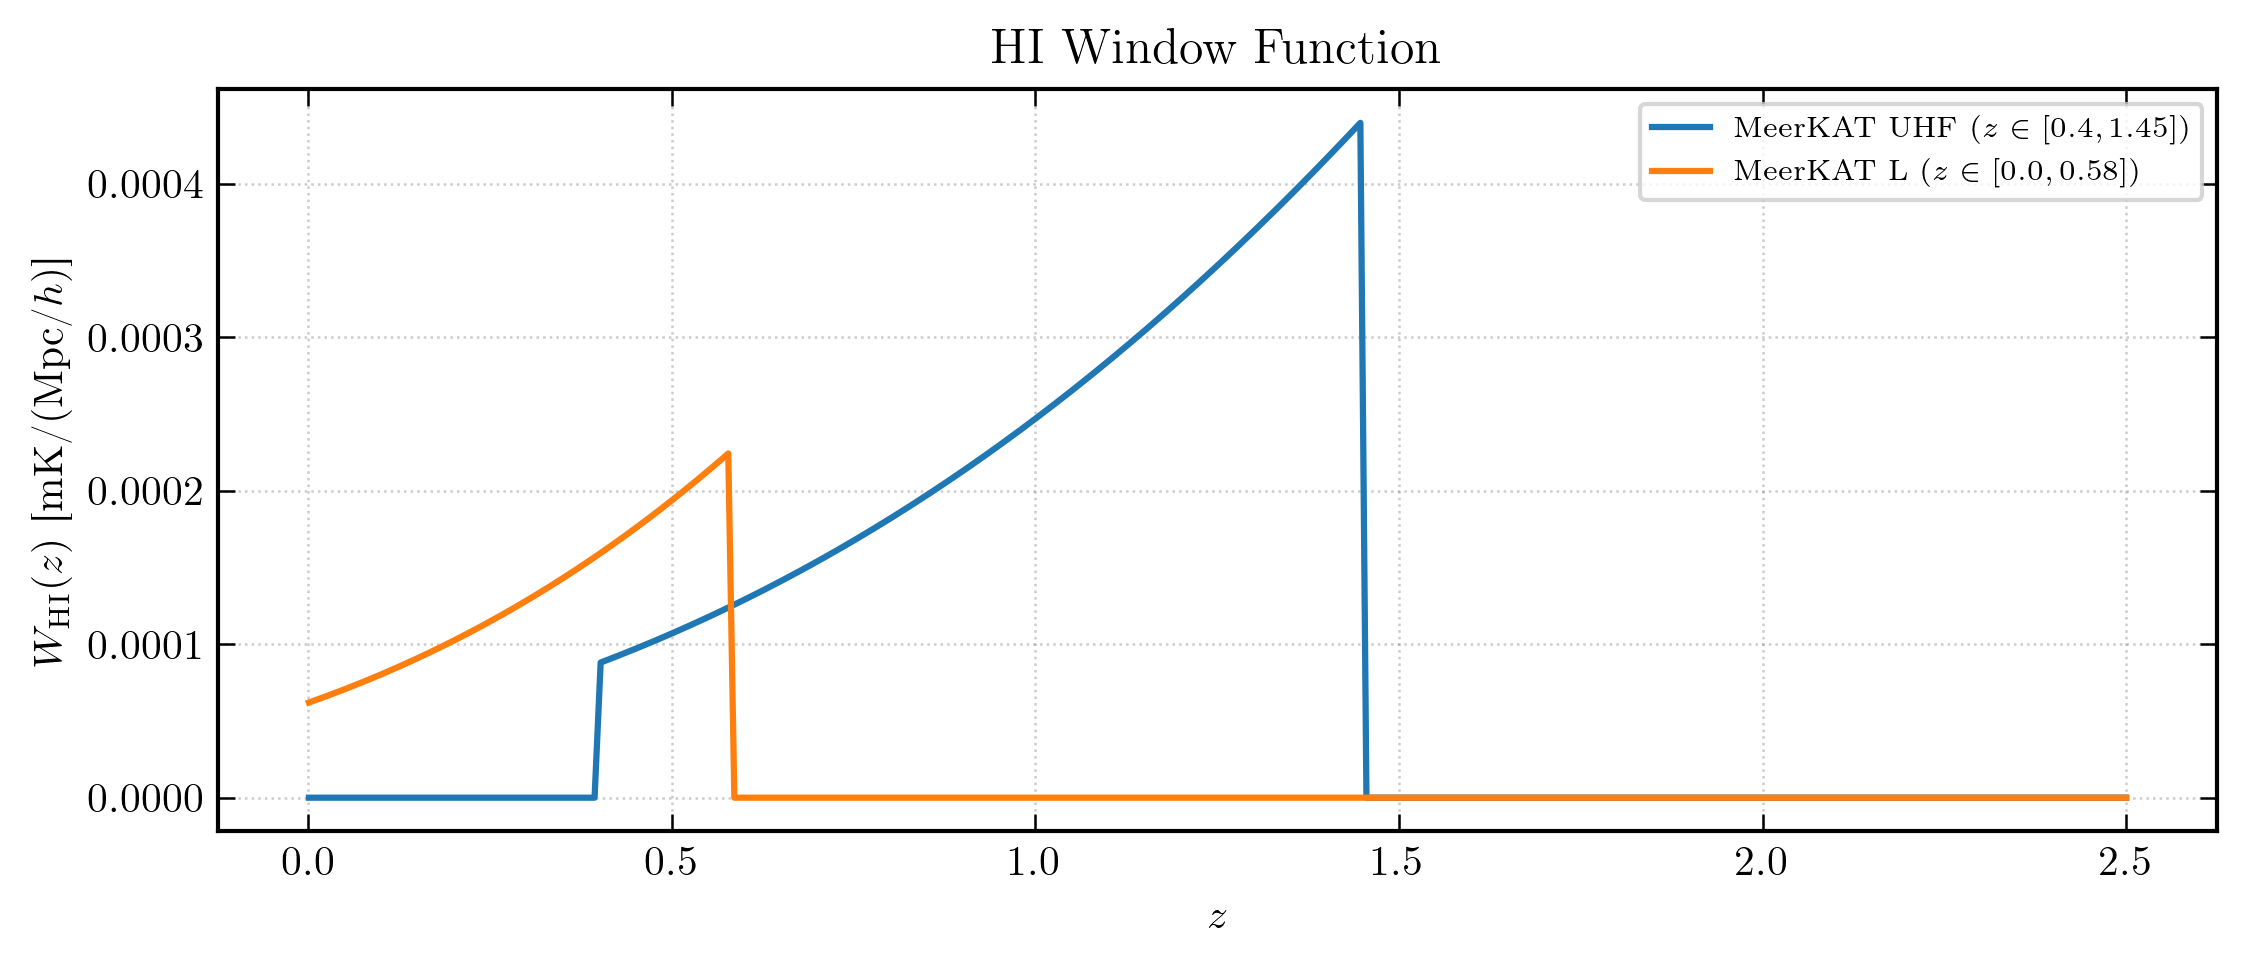

In [35]:
z_w = np.linspace(0.001, 2.5, 300)
bands = [('MeerKAT', 'UHF', 0.4, 1.45), ('MeerKAT', 'L', 0.0, 0.58)]

fig, ax = sty.textwidth_figure(7)
for tel, band, zmin, zmax in bands:
    W = np.array([hi.W_HI(z, zmin, zmax) for z in z_w])
    ax.plot(z_w, W, lw=sty.LW_STANDARD, label=f'{tel} {band} ($z \in [{zmin},{zmax}]$)')
ax.set_xlabel('$z$'); ax.set_ylabel(r'$W_\mathrm{HI}(z)$ [mK/(Mpc/$h$)]')
ax.set_title('HI Window Function'); ax.legend(fontsize=sty.LEGEND_SIZE); fig.tight_layout()

### Intrinsic HI kernel (no band selection)

Without the top-hat $\phi(z)$, the HI brightness kernel is simply
$\bar{T}_b(z) \cdot H(z)/(c\,h)$. This shows the intrinsic redshift
weighting of the HI signal before any instrument band is applied.

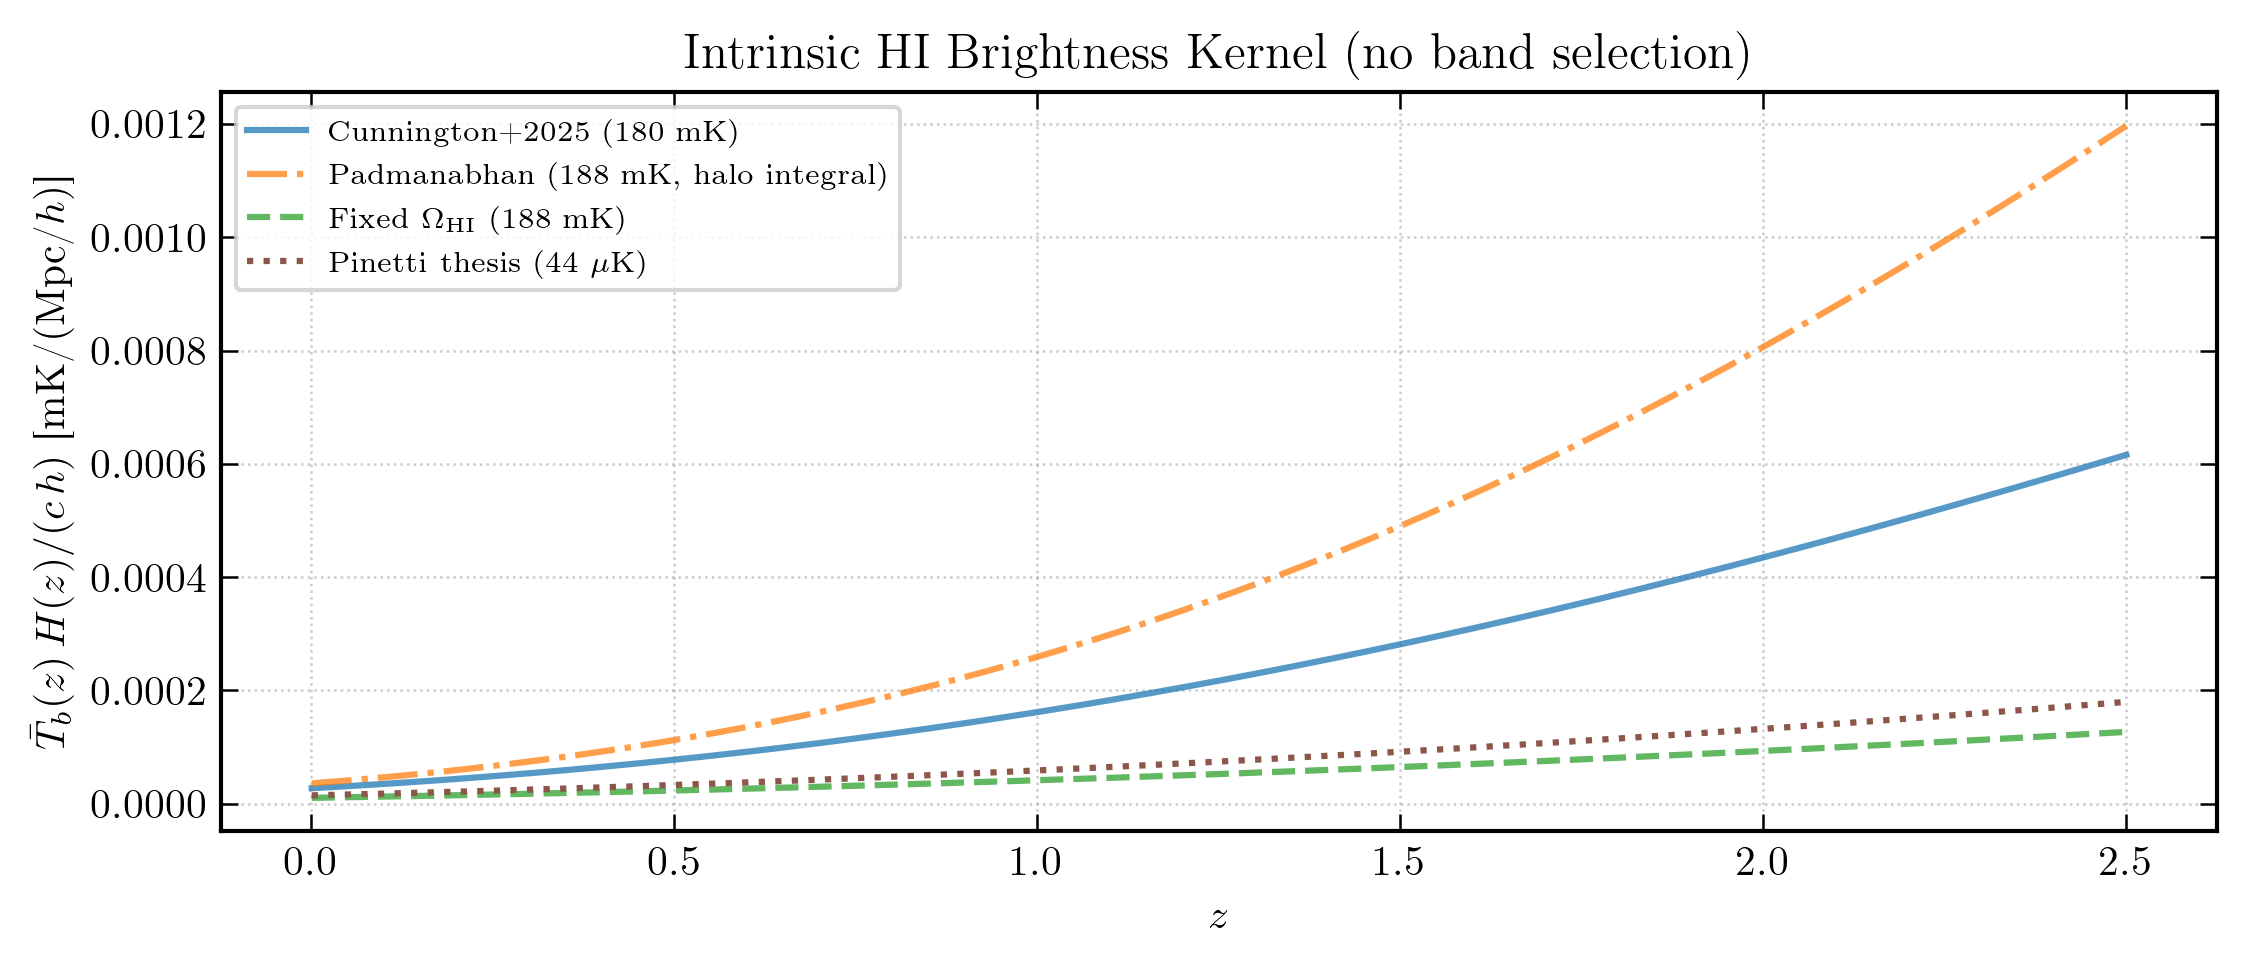

In [36]:
H_over_ch = cosmo.H(z_arr) / (cfg.C_LIGHT_KM_S * cfg.h)  # 1/(Mpc/h)

fig, ax = sty.textwidth_figure(7)
for mode, style, label in [
    ('cunnington', sty.FIT_STYLE, 'Cunnington+2025 (180 mK)'),
    ('padmanabhan', sty.DASHDOT_STYLE, 'Padmanabhan (188 mK, halo integral)'),
    ('fixed_omega', sty.MODEL_STYLE, r'Fixed $\Omega_\mathrm{HI}$ (188 mK)'),
]:
    Tb = np.array([hi.T_bar_b_for_model(z, mode) for z in z_arr])
    kernel = Tb * H_over_ch
    ax.plot(z_arr, kernel, **style, label=label)
# Pinetti thesis: 44 muK pre-evaluated form
kernel_thesis = np.array([p22.T_bar_b_thesis(z) for z in z_arr]) * H_over_ch
ax.plot(z_arr, kernel_thesis, ls=':', color='C5', lw=sty.LW_STANDARD,
        label=r'Pinetti thesis (44 $\mu$K)')
ax.set_xlabel('$z$')
ax.set_ylabel(r'$\bar{T}_b(z)\,H(z)/(c\,h)$ [mK/(Mpc/$h$)]')
ax.set_title('Intrinsic HI Brightness Kernel (no band selection)')
ax.legend(fontsize=sty.LEGEND_SIZE); fig.tight_layout()